Importação das bibliotecas necessárias e leitura dos arquivos

In [33]:
# Importações
import matplotlib.pyplot as plt
import pandas as pd

# Carregamento e exibição dos dataframes
df1 = pd.read_csv("dados1.csv", sep=";")
print("DADOS1.CSV\n", df1.head())

df2 = pd.read_csv("dados2.csv", sep=";")
print("\nDADOS2.CSV\n", df2.head())

df3 = pd.read_excel("dados3.xls")
print("\nDADOS3.CSV\n", df3.head())

DADOS1.CSV
    3,5  4,0  5,5  6,0  5,0 5,5.1 5,0.1 5,5.2 4,0.1  10,0
0  6,5  9,5  4,0  7,0  7,5   3,0   4,5   5,0   2,5   6,0
1  5,0  6,5  3,5  4,5  8,5   4,0   8,0   7,0   6,0   7,5
2  8,5  6,0  9,0  6,0  6,5   7,5   5,5   6,5   8,0   8,5
3  4,5  7,5  8,0  3,0  4,0   8,0   4,5   5,5   6,0   6,0
4  7,5  3,5  3,0  7,0  1,5   4,5  10,0   5,5   2,5  10,0

DADOS2.CSV
      Bairro   Tipo N de quartos  Preço (mil)
0     Barra  Apto.            2          165
1     Barra  Apto.            3          240
2     Barra  Cobt.            3          158
3     Barra   Sala            0           90
4  Botafogo  Apto.            2          270

DADOS3.CSV
   Turma Sexo  Idade   Alt  Peso  Filhos Fuma Toler  Exerc  Cine OpCine  TV  \
0     A    F     17  1.60  60.5       2  NAO     P      0     1      B  16   
1     A    F     18  1.69  55.0       1  NAO     M      0     1      B   7   
2     A    M     18  1.85  72.8       2  NAO     P      5     2      M  15   
3     A    M     25  1.85  80.9       

### 1. O conjunto de dados dados1.csv possue notas de 100 alunos do curso de Economia da FEA-USP, em prova da disciplina Introdução à Probabilidade e à Estatística, 1999. Construe uma distribuição de frequencias e um gráfico para essas notas.

In [36]:
# Função para calcular a distribuição de frequência
# e exibir os gráficos da distribuição calculada
def distribuicao(dataframe, tabelas, vars):
  # Calculando a distribuição de frequência
  for var in vars:
      contagens = dataframe[var].value_counts().sort_index()
      total = contagens.sum()

      fi = contagens.values
      fr = [(v * 100) / total for v in fi]
      Fi = fi.cumsum()
      Fr = [sum(fr[:i+1]) for i in range(len(fr))]

      tabela = pd.DataFrame({
          "Categorias": contagens.index,
          "fi": fi,
          "fr (%)": [f"{v:.1f}%" for v in fr],
          "Fi": Fi,
          "Fr (%)": [f"{v:.1f}%" for v in Fr]
      })

      tabelas[var] = tabela
      print(f"\n===== {var} =====")
      print(tabela.to_string(index=False))

  for var, tabela in tabelas.items():
    fig, ax = plt.subplots(figsize=(8, 4))

    fr_values = tabela["fr (%)"].str.replace("%", "").astype(float)

    ax.bar(tabela["Categorias"].astype(str), fr_values)

    ax.set_title(f"Distribuição de Frequência — {var}")
    ax.set_xlabel(var)
    ax.set_ylabel("Frequência Relativa (%)")

    plt.show()


===== A =====
Categorias  fi fr (%)  Fi Fr (%)
       2,5   1  11.1%   1  11.1%
       3,0   1  11.1%   2  22.2%
       4,0   1  11.1%   3  33.3%
       4,5   1  11.1%   4  44.4%
       5,0   1  11.1%   5  55.6%
       6,5   2  22.2%   7  77.8%
       7,5   1  11.1%   8  88.9%
       8,5   1  11.1%   9 100.0%

===== B =====
Categorias  fi fr (%)  Fi Fr (%)
       3,5   1  11.1%   1  11.1%
       5,0   2  22.2%   3  33.3%
       6,0   1  11.1%   4  44.4%
       6,5   2  22.2%   6  66.7%
       7,5   2  22.2%   8  88.9%
       9,5   1  11.1%   9 100.0%

===== C =====
Categorias  fi fr (%)  Fi Fr (%)
       3,0   1  11.1%   1  11.1%
       3,5   2  22.2%   3  33.3%
       4,0   1  11.1%   4  44.4%
       5,5   1  11.1%   5  55.6%
       7,5   1  11.1%   6  66.7%
       8,0   1  11.1%   7  77.8%
       9,0   2  22.2%   9 100.0%

===== D =====
Categorias  fi fr (%)  Fi Fr (%)
       3,0   1  11.1%   1  11.1%
       4,5   1  11.1%   2  22.2%
       5,5   1  11.1%   3  33.3%
       6,0   3  

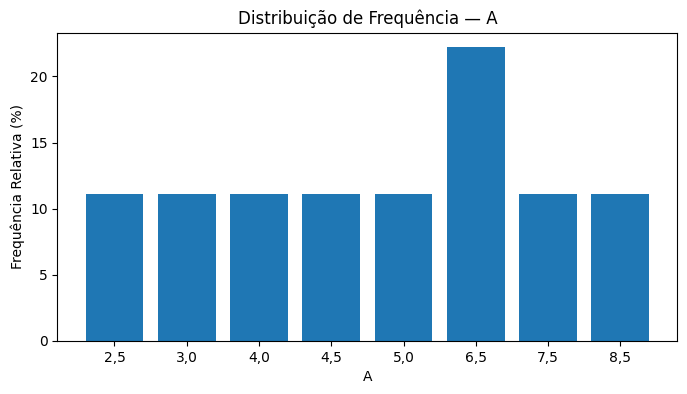

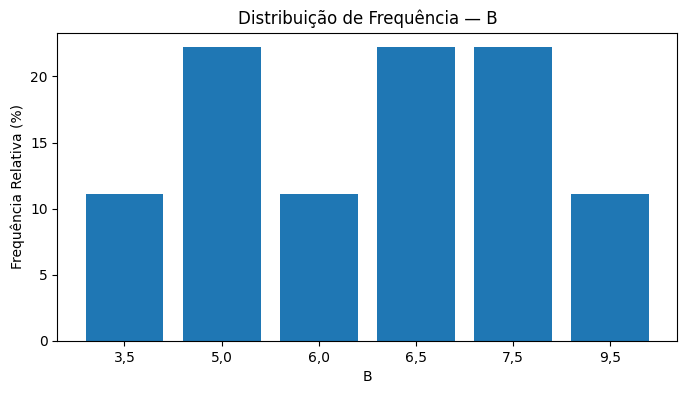

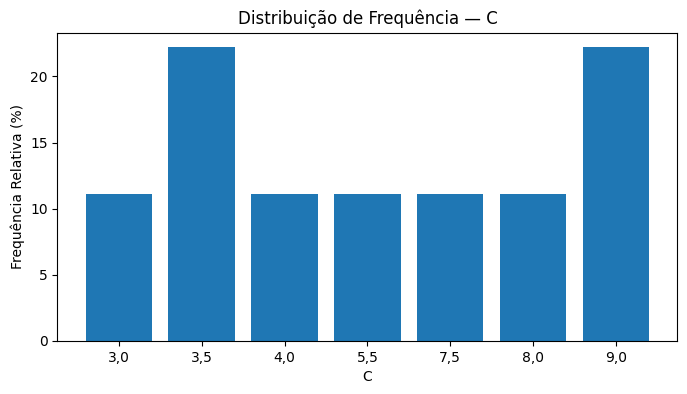

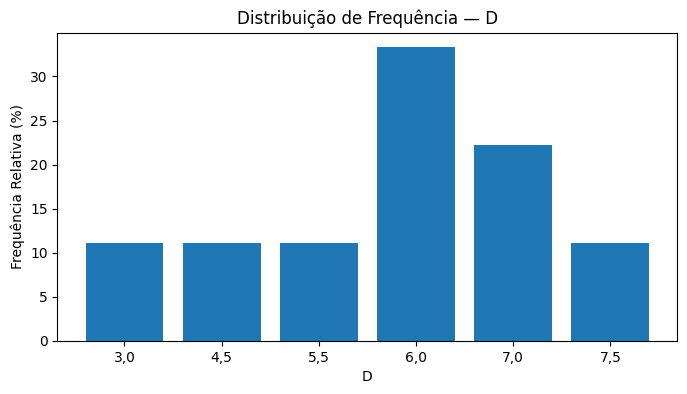

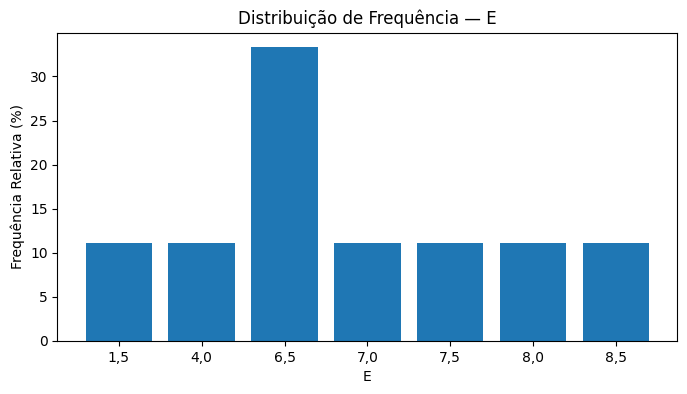

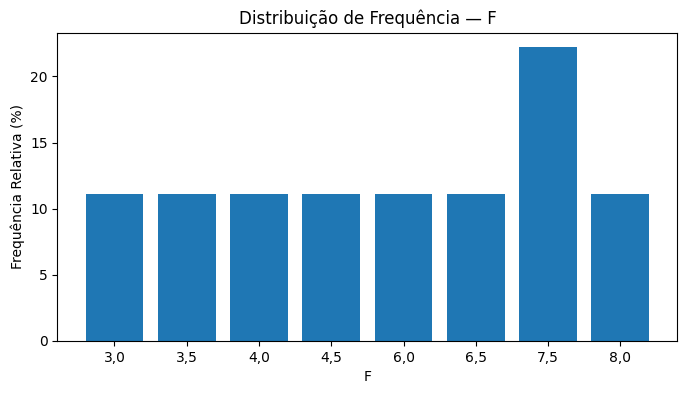

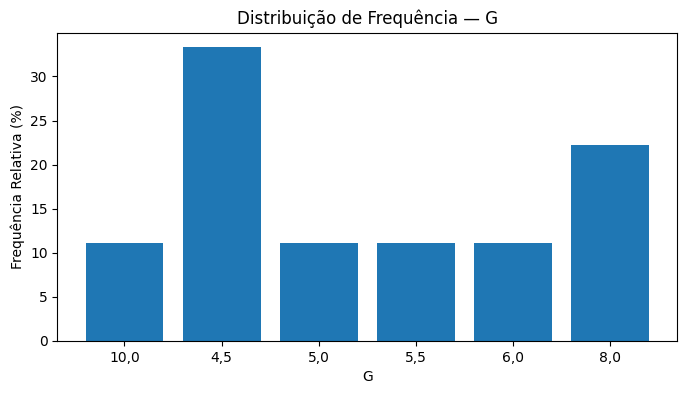

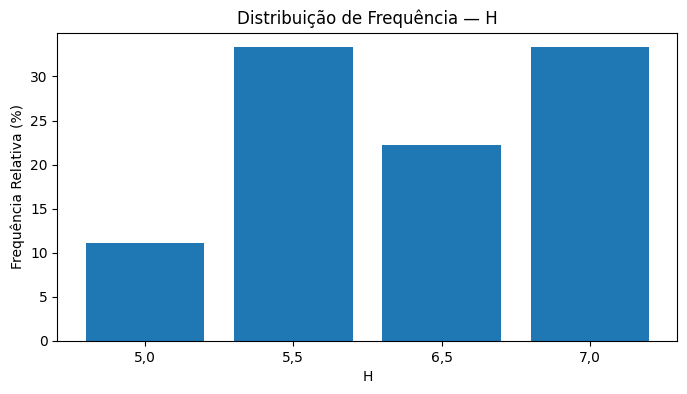

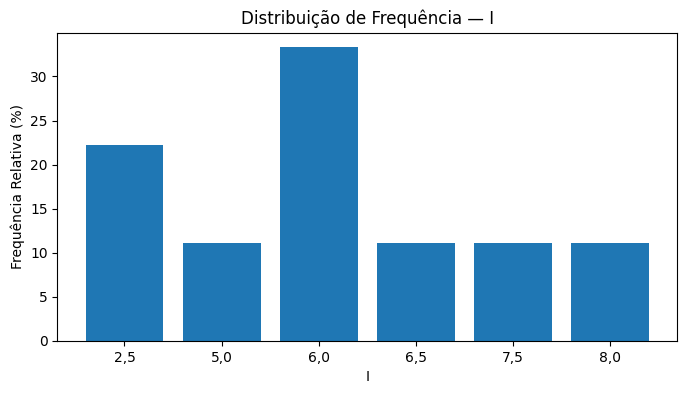

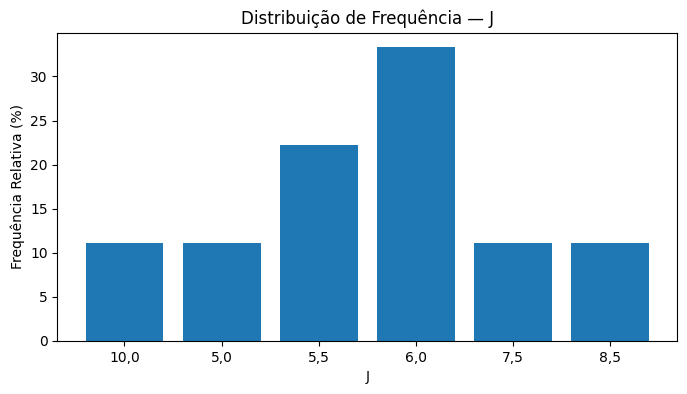

In [37]:
# Criando colunas para o df1 para manipulação dos dados
df1_vars = ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J"]
df1.columns = vars

df1_tabelas = {}
distribuicao(df1, df1_tabelas, df1_vars)

### 2. O conjunto de dados dados2.csv mostra os dados brutos de uma amostra de 27 imóveis anunciados para venda nos anúncios de um site especializado. Nesse exemplo, cada observação é um imóvel e cada variável é um atributo dos imóveis (bairro, tipo, número de quartos, preço).

Com base nesses dados:

  - a. classifique cada variável do conjunto;
  - b. monte uma distribuição de frequência para cada uma das variáveis;
  - c. crie um gráfico representando cada uam das variáveis disponíveis.

**dados1:**

- Quantitativa contínua porque a variável armazena valores numéricos fracionários

**dados2:**

- Bairro: Qualitativa nominal porque a variável não armazena valores numéricos e não segue uma ordem hierárquica

- Tipo: Qualitativa nominal porque a variável não armazena valores numéricos e não segue uma ordem hierárquica

- N de quartos: Quantitativa discreta porque armazena contagem de valores inteiros

- Preço (mil): Quantitativa discreta porque armazena contagem de valores inteiros



### 3. O conjunto de dados dados3.xls traz informações sobre um questionário aplicado aos alunos do primeiro ano do ensino médio de uma escola fornecendo informações sobre as seguintes variáveis:

(a) classifique cada variável do conjunto;

- Turma: Qualitativa ordinal porque não armazena valores numéricos e os dados seguem uma ordem hierárquica

- Gẽnero: Qualitativa nominal porque não armazenaa valores numéricos e os dados não seguem  uma ordem hierárquica

- Idade: Quantitativa discreta porque armazena valores inteiros não hierárquicos

- Alt: Quantitativa contínua porque armazena valores fracionários não hierárquicos

- Peso: Quantitativa contínua porque armazena valores fracionários não hierárquicos

- Filhos: Quantitativa discreta porque armazena valores inteiros não hierárquicos

- Fuma: Qualitativa nominal porque não aramzena dados numéricos e os valores não seguem uma ordem hierárquica

- Toler: Qualitativa contínua porque não armazena dados numéricos e os valores seguem uma ordem hierárquica

- Exerc: Quantitativa porque armazena valores numéricos não hierárquicos

- Cine: Quantitativa porque armazena valores numéricos não hierárquicos

- TV: Quantitativa porque armazena valores numéricos não hierárquicos

- OpTV: Qualitativa contínua porque não armazena dados numéricos e os valores seguem uma ordem hierárquica

(b) monte uma distribuição de frequência para cada uma das variáveis;

(c) crie um gráfico representando cada uma das variáveis disponíveis.


===== Turma =====
Categorias  fi fr (%)  Fi Fr (%)
         A  26  52.0%  26  52.0%
         B  24  48.0%  50 100.0%

===== Sexo =====
Categorias  fi fr (%)  Fi Fr (%)
         F  37  74.0%  37  74.0%
         M  13  26.0%  50 100.0%

===== Idade =====
 Categorias  fi fr (%)  Fi Fr (%)
         17   9  18.0%   9  18.0%
         18  22  44.0%  31  62.0%
         19   7  14.0%  38  76.0%
         20   4   8.0%  42  84.0%
         21   3   6.0%  45  90.0%
         23   2   4.0%  47  94.0%
         24   1   2.0%  48  96.0%
         25   2   4.0%  50 100.0%

===== Alt =====
 Categorias  fi fr (%)  Fi Fr (%)
       1.45   1   2.0%   1   2.0%
       1.54   1   2.0%   2   4.0%
       1.55   3   6.0%   5  10.0%
       1.57   2   4.0%   7  14.0%
       1.58   1   2.0%   8  16.0%
       1.60   5  10.0%  13  26.0%
       1.61   1   2.0%  14  28.0%
       1.62   3   6.0%  17  34.0%
       1.63   1   2.0%  18  36.0%
       1.64   2   4.0%  20  40.0%
       1.65   4   8.0%  24  48.0%
       1.66   1

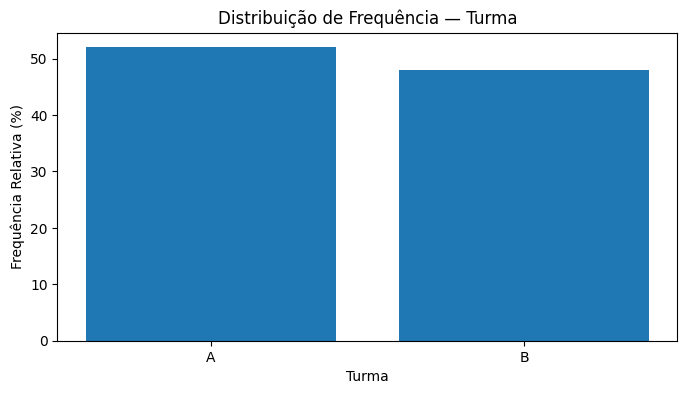

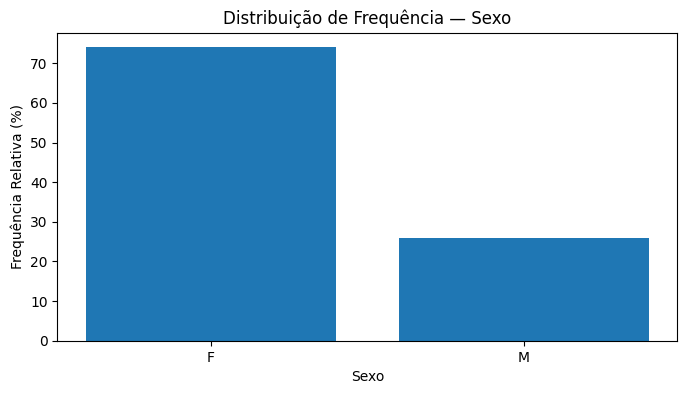

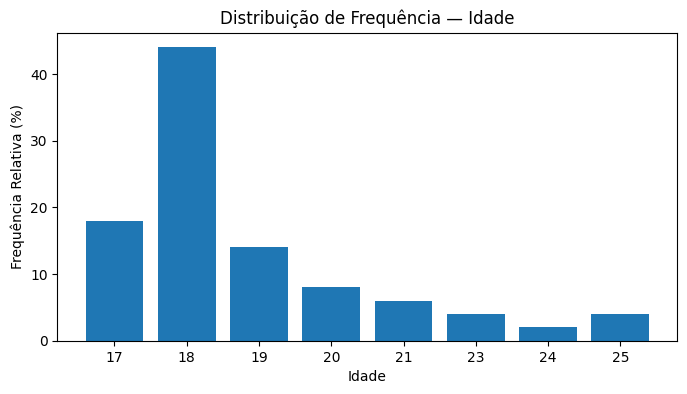

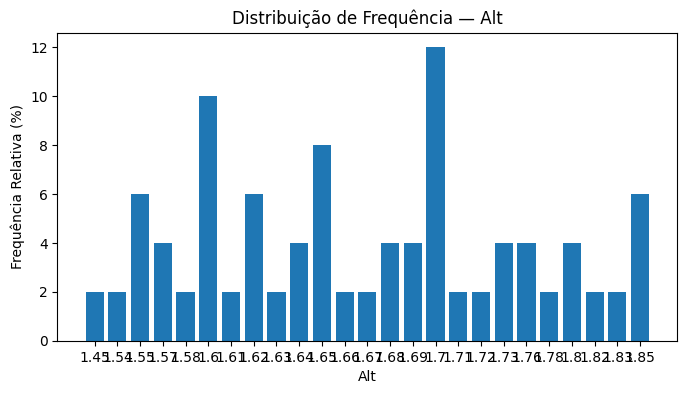

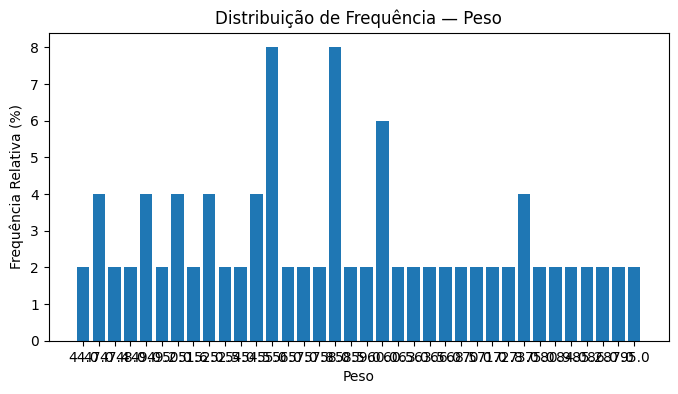

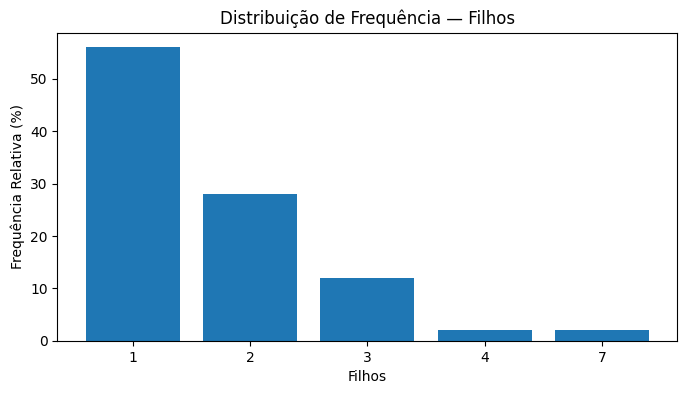

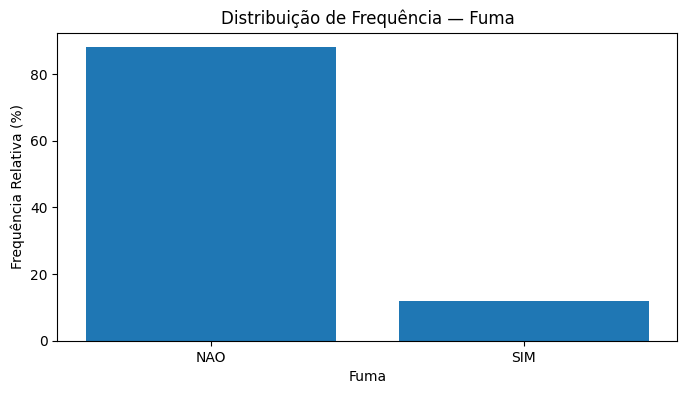

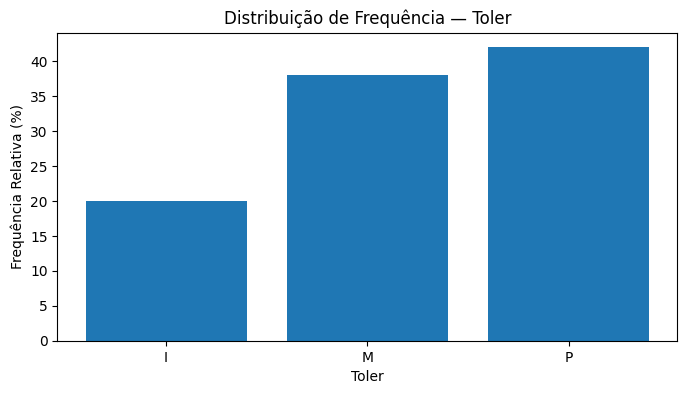

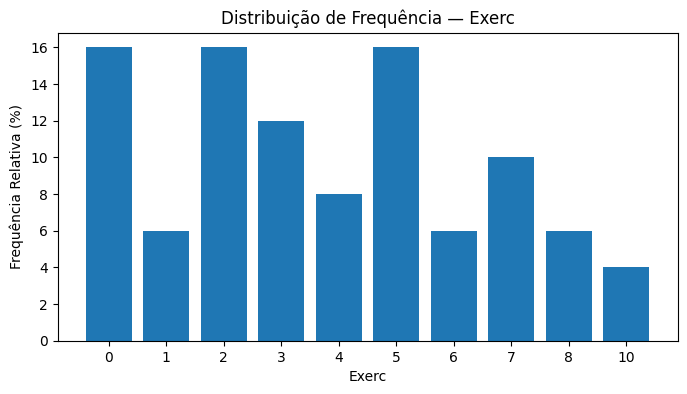

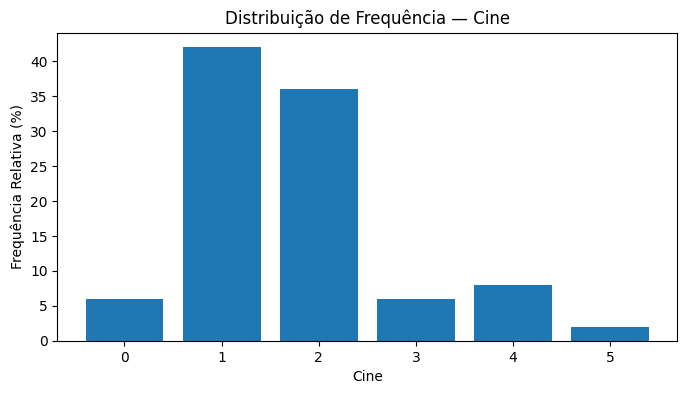

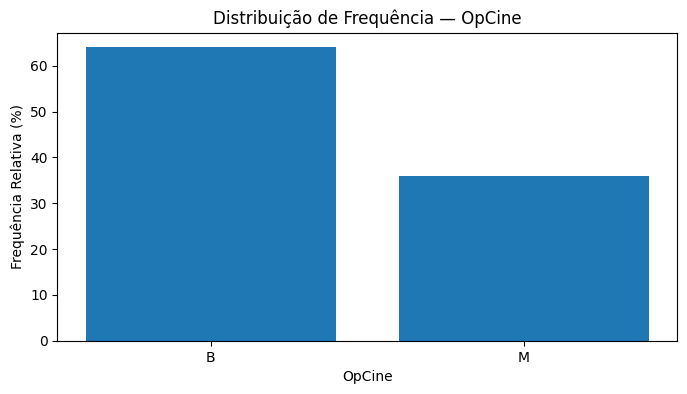

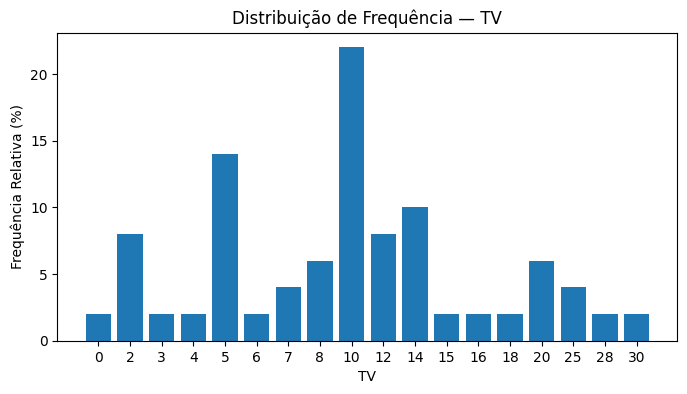

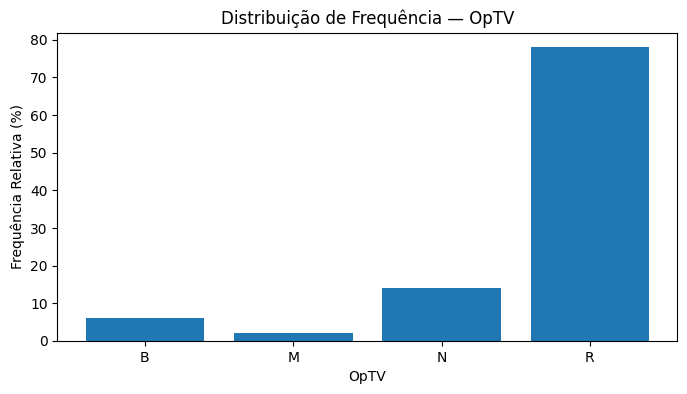

In [32]:
df3_vars = [
    "Turma", "Sexo", "Idade", "Alt",
    "Peso", "Filhos", "Fuma", "Toler",
    "Exerc", "Cine", "OpCine", "TV", "OpTV"
]

df3_tabelas = {}
distribuicao(df3, df3_tabelas, df3_vars)